# FaceNet: A Unified Embedding for Face Recognition and Clustering
**Implementation based on:** Schroff et al., 2015 (arXiv:1503.03832)  
**Kaggle-ready version — VGGFace2 CS338 dataset**

---
| Setting | Value | Source |
|---|---|---|
| Architecture | **NN2** — Inception-based | Table 2 |
| Input size | **160×160** (NN3 variant) | Table 2 footnote |
| Embedding | **128-D**, L2-normalised | §5.4 |
| Loss | **Triplet Loss**, margin α=0.2 | Eq. 3, §3.3 |
| Optimiser | **SGD + AdaGrad**, lr=0.05 | §3.3 |
| Training data | **VGGFace2 CS338** — Kaggle dataset | Academic dataset |
| Evaluation | **VGGFace2 val set + LFW** — VAL @ FAR=10⁻³ | §4.3, §5.6 |

---
**Kaggle dataset path:** 
1. For Training :
`/kaggle/input/datasets/huphuoc09/vgg-face2-cs338`  
Add the dataset via: **+ Add Input → select Datasets → search "vggface2-cs338"**

2. For Testing :
`/kaggle/input/datasets/jessicali9530/lfw-dataset`  
Add the dataset via: **+ Add Input → select Datasets → search "lfw-dataset"**

## 1. Environment Setup & Imports

In [1]:

import os
import random
import time
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import torchvision.transforms as transforms
from sklearn.metrics import roc_curve, auc

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM   : {vram:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2. Configuration

> **VGGFace2 already ships with a train/val split** — we use it directly.  
> Paths point to the Kaggle input directory for VGGFace2 CS338.

In [2]:
print(os.listdir('/kaggle/input/datasets/huphuoc09/vgg-face2-cs338/VGG-Face2/data/vggface2_test')[:5])

['test']


In [3]:
class Config:
    INPUT_SIZE    = 160
    EMBEDDING_DIM = 128        # paper §5.4

    MARGIN        = 0.2        # α, paper §3.3

    LEARNING_RATE  = 0.05
    LR_DECAY_STEP  = 10
    LR_DECAY_GAMMA = 0.1

    FACES_PER_ID   = 20        # reduced from 40 for Kaggle VRAM budget
    IDS_PER_BATCH  = 18
    BATCH_SIZE     = FACES_PER_ID * IDS_PER_BATCH   # 360

    NUM_EPOCHS      = 20       # hard upper limit
    EARLY_STOP_PATIENCE = 3    # stop if val_loss doesn't improve for this many epochs
    MIXED_PRECISION = True
    GRAD_CLIP       = 5.0

    DATASET_ROOT = '/kaggle/input/datasets/huphuoc09/vgg-face2-cs338/VGG-Face2/data'
    TRAIN_DIR    = DATASET_ROOT + '/vggface2_train/train'
    VAL_DIR      = DATASET_ROOT + '/vggface2_test/test'

    # Minimum images per identity to include
    MIN_IMAGES = 20

    LFW_DIR        = '/kaggle/working/lfw'
    LFW_PAIRS_FILE = '/kaggle/working/lfw/pairs.txt'

    FAR_TARGET = 1e-3
    THRESHOLD  = 1.242         # optimal LFW threshold (paper §5.6)

    CHECKPOINT_DIR = '/kaggle/working/checkpoints'
    LOG_DIR        = '/kaggle/working/logs'


cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(cfg.LOG_DIR, exist_ok=True)

# Verify dataset exists
if not os.path.exists(cfg.TRAIN_DIR):
    print(f'[WARNING] TRAIN_DIR not found: {cfg.TRAIN_DIR}')
    print('Please add the vggface2-cs338 dataset via "+ Add Data"')
else:
    print(f'Train dir        : {cfg.TRAIN_DIR}  ✓')
    print(f'Val   dir        : {cfg.VAL_DIR}')
    print(f'Input size       : {cfg.INPUT_SIZE}×{cfg.INPUT_SIZE}')
    print(f'Embedding dim    : {cfg.EMBEDDING_DIM}')
    print(f'Triplet margin α : {cfg.MARGIN}')
    print(f'Batch            : {cfg.IDS_PER_BATCH} IDs × {cfg.FACES_PER_ID} faces = {cfg.BATCH_SIZE}')
    print(f'Learning rate    : {cfg.LEARNING_RATE}')
    print(f'Mixed precision  : {cfg.MIXED_PRECISION}')

Train dir        : /kaggle/input/datasets/huphuoc09/vgg-face2-cs338/VGG-Face2/data/vggface2_train/train  ✓
Val   dir        : /kaggle/input/datasets/huphuoc09/vgg-face2-cs338/VGG-Face2/data/vggface2_test/test
Input size       : 160×160
Embedding dim    : 128
Triplet margin α : 0.2
Batch            : 18 IDs × 20 faces = 360
Learning rate    : 0.05
Mixed precision  : True


## 3. VGGFace2 Dataset Statistics

**VGGFace2 facts:**
- ~3.31 million images total  
- **8,631 train identities** / **500 val identities** (provided split)  
- Average ~362 images per identity

In [4]:
import os
base = '/kaggle/input/datasets/huphuoc09/vgg-face2-cs338/VGG-Face2/data/vggface2_train'
# Check top level
print("Top level:", os.listdir(base)[:5])

# Go one deeper
first = os.listdir(base)[0]
print("Inside first folder:", os.listdir(os.path.join(base, first))[:5])

# Go one more deeper if needed
second = os.listdir(os.path.join(base, first))[0]
print("Inside second folder:", os.listdir(os.path.join(base, first, second))[:5])

Top level: ['train']
Inside first folder: ['n008215', 'n008964', 'n003375', 'n008905', 'n002619']
Inside second folder: ['0429_01.jpg', '0432_01.jpg', '0085_01.jpg', '0030_01.jpg', '0262_02.jpg']


In [5]:
def dataset_stats(root_dir, name, min_images=1):
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f'{name} not found at {root.resolve()}')

    identity_dirs = sorted([d for d in root.iterdir() if d.is_dir()])
    counts = []
    for d in tqdm(identity_dirs, desc=f'Scanning {name}', leave=False):
        n = len([f for f in d.iterdir()
                 if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
        counts.append(n)

    counts = np.array(counts)
    kept   = (counts >= min_images).sum()

    print(f'\n── {name} ──')
    print(f'  Total identities      : {len(counts):,}')
    print(f'  Total images          : {counts.sum():,}')
    print(f'  Avg images/identity   : {counts.mean():.1f}')
    print(f'  Median images/id      : {int(np.median(counts))}')
    print(f'  Min / Max             : {counts.min()} / {counts.max()}')
    print(f'  Identities ≥{min_images} images : {kept:,}  ({kept/len(counts)*100:.1f}%)')

    return identity_dirs, counts


train_id_dirs, train_counts = dataset_stats(cfg.TRAIN_DIR, 'VGGFace2 TRAIN', cfg.MIN_IMAGES)
val_id_dirs,   val_counts   = dataset_stats(cfg.VAL_DIR,   'VGGFace2 VAL',   min_images=2)


── VGGFace2 TRAIN ──
  Total identities      : 8,631
  Total images          : 3,141,890
  Avg images/identity   : 364.0
  Median images/id      : 359
  Min / Max             : 87 / 843
  Identities ≥20 images : 8,631  (100.0%)



── VGGFace2 VAL ──
  Total identities      : 500
  Total images          : 169,396
  Avg images/identity   : 338.8
  Median images/id      : 325
  Min / Max             : 98 / 761
  Identities ≥2 images : 500  (100.0%)


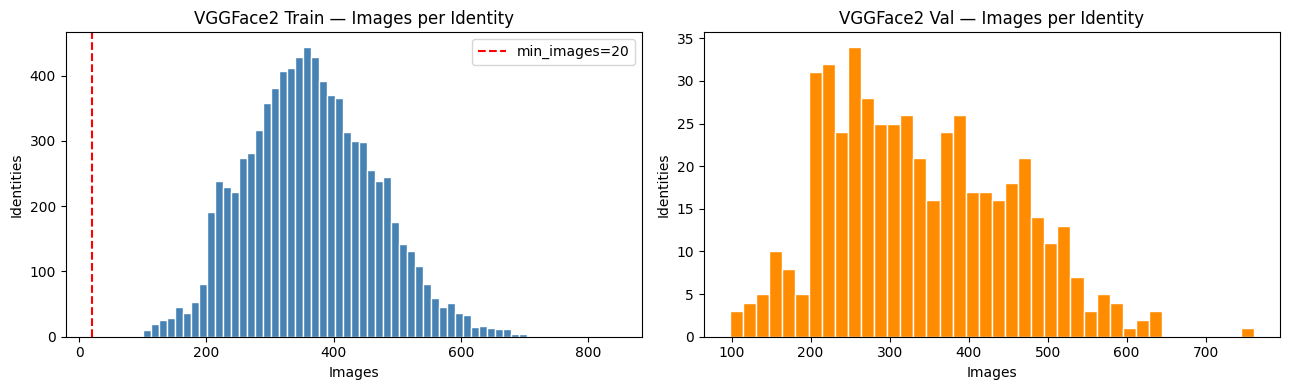

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train_counts, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(cfg.MIN_IMAGES, color='red', linestyle='--',
                label=f'min_images={cfg.MIN_IMAGES}')
axes[0].set_title('VGGFace2 Train — Images per Identity')
axes[0].set_xlabel('Images'); axes[0].set_ylabel('Identities')
axes[0].legend()

axes[1].hist(val_counts, bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('VGGFace2 Val — Images per Identity')
axes[1].set_xlabel('Images'); axes[1].set_ylabel('Identities')

plt.tight_layout()
plt.savefig(os.path.join(cfg.LOG_DIR, 'vggface2_stats.png'), dpi=150)
plt.show()

## 4. Preprocessing Pipeline

VGGFace2 images are already **face-detected and loosely aligned**.

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((cfg.INPUT_SIZE, cfg.INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomGrayscale(p=0.01),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((cfg.INPUT_SIZE, cfg.INPUT_SIZE)),
    transforms.CenterCrop(cfg.INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

print('Train transform:', [type(t).__name__ for t in train_transform.transforms])
print('Eval  transform:', [type(t).__name__ for t in eval_transform.transforms])

Train transform: ['Resize', 'RandomHorizontalFlip', 'ColorJitter', 'RandomGrayscale', 'ToTensor', 'Normalize']
Eval  transform: ['Resize', 'CenterCrop', 'ToTensor', 'Normalize']


## 5. Dataset & DataLoader

In [8]:
class FaceDataset(Dataset):
    """
    Flat image list from a root directory with identity sub-folders.
    Expected layout:
        root/
            n000002/  img1.jpg  img2.jpg ...
            n000003/  ...
    """
    def __init__(self, root, transform=None, min_images=2):
        self.root      = Path(root)
        self.transform = transform

        self.image_paths      = []
        self.labels           = []
        self.label_to_indices = defaultdict(list)
        self.label_to_name    = {}

        label_idx = 0
        for id_dir in tqdm(sorted(self.root.iterdir()),
                           desc=f'Indexing {self.root.name}', leave=False):
            if not id_dir.is_dir():
                continue
            imgs = sorted([
                p for p in id_dir.iterdir()
                if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
            ])
            if len(imgs) < min_images:
                continue
            self.label_to_name[label_idx] = id_dir.name
            for img_path in imgs:
                flat_idx = len(self.image_paths)
                self.image_paths.append(img_path)
                self.labels.append(label_idx)
                self.label_to_indices[label_idx].append(flat_idx)
            label_idx += 1

        self.num_classes = label_idx

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


print('Building train dataset...')
train_dataset = FaceDataset(cfg.TRAIN_DIR, transform=train_transform,
                             min_images=cfg.MIN_IMAGES)
print('Building val dataset...')
val_dataset   = FaceDataset(cfg.VAL_DIR,   transform=eval_transform,
                             min_images=2)

print(f'\nTrain : {len(train_dataset):,} images  |  {train_dataset.num_classes:,} identities')
print(f'Val   : {len(val_dataset):,} images  |  {val_dataset.num_classes:,} identities')

Building train dataset...


Building val dataset...



Train : 3,141,890 images  |  8,631 identities
Val   : 169,396 images  |  500 identities


In [10]:
class BalancedBatchSampler(Sampler):
    """
    Yields index lists where each selected identity contributes
    exactly n_samples images. Total per batch = n_ids × n_samples.
    """
    def __init__(self, dataset, n_samples, n_ids_per_batch):
        self.label_to_indices = dataset.label_to_indices
        self.all_labels       = list(self.label_to_indices.keys())
        self.n_samples        = n_samples
        self.n_ids            = n_ids_per_batch
        self.n_batches        = len(self.all_labels) // self.n_ids

    def __len__(self):
        return self.n_batches

    def __iter__(self):
        shuffled = self.all_labels.copy()
        random.shuffle(shuffled)
        for b in range(self.n_batches):
            batch_labels = shuffled[b * self.n_ids : (b+1) * self.n_ids]
            indices = []
            for label in batch_labels:
                pool = self.label_to_indices[label]
                chosen = (random.sample(pool, self.n_samples)
                          if len(pool) >= self.n_samples
                          else random.choices(pool, k=self.n_samples))
                indices.extend(chosen)
            yield indices


batch_sampler = BalancedBatchSampler(
    train_dataset,
    n_samples       = cfg.FACES_PER_ID,
    n_ids_per_batch = cfg.IDS_PER_BATCH,
)

# FIX: Use num_workers=4 on Kaggle (Linux), not 0
train_loader = DataLoader(
    train_dataset,
    batch_sampler = batch_sampler,
    num_workers   = 4,        # ← 4 on Kaggle/Linux; use 0 only on Windows
    pin_memory    = DEVICE.type == 'cuda',
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = 64,
    shuffle     = False,
    num_workers = 4,
    pin_memory  = DEVICE.type == 'cuda',
)

print(f'Train batches / epoch : {len(train_loader):,}')
print(f'Effective batch size  : {cfg.BATCH_SIZE}')

Train batches / epoch : 479
Effective batch size  : 360


## 6. NN2 Architecture (Table 2 of the paper)

Two modifications vs. vanilla GoogLeNet:
- **L2 pooling** instead of max-pooling at specified layers
- **128-D FC + L2 normalisation** head — no softmax

In [11]:
class L2Pool2d(nn.Module):
    """sqrt(AvgPool(x²)) — the paper's L2 pooling variant."""
    def __init__(self, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.pool = nn.AvgPool2d(kernel_size, stride=stride, padding=padding)
    def forward(self, x):
        return torch.sqrt(self.pool(x.pow(2)) + 1e-10)


class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding=0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride,
                      padding=padding, bias=False),
            nn.BatchNorm2d(out_ch, eps=1e-3),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class InceptionModule(nn.Module):
    """
    Covers all Inception variants from Table 2.
    stride=2 → spatial downsampling (inception 3c, 4e).
    pool_type : 'max' | 'l2'
    """
    def __init__(self, in_ch, out_1x1,
                 reduce_3x3, out_3x3,
                 reduce_5x5, out_5x5,
                 out_pool, pool_type='l2', stride=1):
        super().__init__()
        self.has_1x1 = out_1x1 > 0
        if self.has_1x1:
            self.branch1 = ConvBnRelu(in_ch, out_1x1, 1)
        self.branch2 = nn.Sequential(
            ConvBnRelu(in_ch, reduce_3x3, 1),
            ConvBnRelu(reduce_3x3, out_3x3, 3, stride=stride, padding=1),
        )
        self.branch3 = nn.Sequential(
            ConvBnRelu(in_ch, reduce_5x5, 1),
            ConvBnRelu(reduce_5x5, out_5x5, 5, stride=stride, padding=2),
        )
        pool_layer = (L2Pool2d(3, stride=stride, padding=1)
                      if pool_type == 'l2'
                      else nn.MaxPool2d(3, stride=stride, padding=1))
        self.has_pool_proj = out_pool > 0
        if self.has_pool_proj:
            self.branch4 = nn.Sequential(pool_layer, ConvBnRelu(in_ch, out_pool, 1))
        else:
            self.branch4 = pool_layer   # pass-through (for stride-2 downsampling)

    def forward(self, x):
        out = []
        if self.has_1x1:
            out.append(self.branch1(x))
        out += [self.branch2(x), self.branch3(x), self.branch4(x)]
        return torch.cat(out, dim=1)


class NN2(nn.Module):
    """
    FaceNet NN2 (Schroff et al. Table 2).
    Input : (B, 3, INPUT_SIZE, INPUT_SIZE)
    Output: (B, 128)  — L2-normalised unit-norm embedding
    """
    def __init__(self, embedding_dim=128):
        super().__init__()
        # Stem
        self.conv1 = ConvBnRelu(3, 64, 7, stride=2, padding=3)
        self.pool1 = nn.MaxPool2d(3, stride=2, padding=1)
        self.norm1 = nn.LocalResponseNorm(5, alpha=1e-4, beta=0.75, k=2)
        self.conv2 = nn.Sequential(ConvBnRelu(64, 64, 1),
                                   ConvBnRelu(64, 192, 3, padding=1))
        self.norm2 = nn.LocalResponseNorm(5, alpha=1e-4, beta=0.75, k=2)
        self.pool2 = nn.MaxPool2d(3, stride=2, padding=1)

        # Stage 3 — input 192ch
        self.inc3a = InceptionModule(192,  64,  96, 128, 16,  32,  32, 'max')   # →256
        self.inc3b = InceptionModule(256,  64,  96, 128, 32,  64,  64, 'l2')    # →320
        self.inc3c = InceptionModule(320,   0, 128, 256, 32,  64,   0, 'max', stride=2)  # →640

        # Stage 4 — input 640ch
        self.inc4a = InceptionModule(640, 256,  96, 192, 32,  64, 128, 'l2')   # →640
        self.inc4b = InceptionModule(640, 224, 112, 224, 32,  64, 128, 'l2')   # →640
        self.inc4c = InceptionModule(640, 192, 128, 256, 32,  64, 128, 'l2')   # →640
        self.inc4d = InceptionModule(640, 160, 144, 288, 32,  64, 128, 'l2')   # →640
        self.inc4e = InceptionModule(640,   0, 160, 256, 64, 128,   0, 'max', stride=2)  # →1024

        # Stage 5 — input 1024ch
        self.inc5a = InceptionModule(1024, 384, 192, 384, 48, 128, 128, 'l2')  # →1024
        self.inc5b = InceptionModule(1024, 384, 192, 384, 48, 128, 128, 'max') # →1024

        # Head
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout  = nn.Dropout(p=0.4)
        self.fc       = nn.Linear(1024, embedding_dim, bias=False)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    def forward(self, x):
        x = self.pool1(self.conv1(x))
        x = self.norm1(x)
        x = self.pool2(self.norm2(self.conv2(x)))
        x = self.inc3c(self.inc3b(self.inc3a(x)))
        x = self.inc4e(self.inc4d(self.inc4c(self.inc4b(self.inc4a(x)))))
        x = self.inc5b(self.inc5a(x))
        x = self.avg_pool(x).flatten(1)
        x = self.dropout(x)
        x = self.fc(x)
        x = F.normalize(x, p=2, dim=1)   # ||f(x)||₂ = 1  (§3.1)
        return x


model = NN2(embedding_dim=cfg.EMBEDDING_DIM).to(DEVICE)
with torch.no_grad():
    dummy = torch.randn(4, 3, cfg.INPUT_SIZE, cfg.INPUT_SIZE).to(DEVICE)
    out   = model(dummy)

total_params = sum(p.numel() for p in model.parameters())
print(f'Output shape : {out.shape}')          # (4, 128)
print(f'L2 norms     : {out.norm(dim=1)}')    # all ≈ 1.0
print(f'Total params : {total_params:,}')

Output shape : torch.Size([4, 128])
L2 norms     : tensor([1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0')
Total params : 7,464,096


## 7. Triplet Loss (Equation 3 of the paper)

$$\mathcal{L} = \sum_i^N \left[ \|f(x_i^a) - f(x_i^p)\|_2^2 - \|f(x_i^a) - f(x_i^n)\|_2^2 + \alpha \right]_+, \quad \alpha = 0.2$$

In [12]:
class TripletLoss(nn.Module):
    def __init__(self, margin=0.2):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        """
        anchor, positive, negative : (N, 128) L2-normalised tensors
        Returns: loss (scalar), frac_active (float in [0,1])
        """
        d_pos  = (anchor - positive).pow(2).sum(1)
        d_neg  = (anchor - negative).pow(2).sum(1)
        losses = F.relu(d_pos - d_neg + self.margin)
        frac_active = (losses > 0).float().mean().item()
        return losses.mean(), frac_active


triplet_loss_fn = TripletLoss(margin=cfg.MARGIN)
print(f'TripletLoss initialised with α={cfg.MARGIN}')

TripletLoss initialised with α=0.2


## 8. Semi-Hard Negative Mining (Section 3.2)

Semi-hard negatives: $d(a,p) < d(a,n) < d(a,p) + \alpha$

In [13]:
def build_triplet_indices(embeddings, labels, margin):
    """
    Online semi-hard negative mining (§3.2).
    1. Prefer semi-hard: d(a,p) < d(a,n) < d(a,p)+margin
    2. Fallback to hardest negative if none found
    Returns: a_idx, p_idx, n_idx — 1-D LongTensors
    """
    emb    = embeddings.detach().float()
    labels = labels.to(emb.device)

    dist   = (emb.unsqueeze(1) - emb.unsqueeze(0)).pow(2).sum(2)
    same   = (labels.unsqueeze(1) == labels.unsqueeze(0))
    diff   = ~same

    a_list, p_list, n_list = [], [], []

    for a in range(len(emb)):
        pos_mask = same[a].clone()
        pos_mask[a] = False
        pos_ids = pos_mask.nonzero(as_tuple=True)[0]
        neg_ids = diff[a].nonzero(as_tuple=True)[0]

        if len(pos_ids) == 0 or len(neg_ids) == 0:
            continue

        for p in pos_ids:
            d_ap = dist[a, p]
            d_an = dist[a, neg_ids]

            sh = (d_an > d_ap) & (d_an < d_ap + margin)
            if sh.any():
                cand = d_an.clone()
                cand[~sh] = float('inf')
                n_local = cand.argmin()
            else:
                n_local = d_an.argmin()

            a_list.append(a)
            p_list.append(p.item())
            n_list.append(neg_ids[n_local].item())

    if not a_list:
        return None, None, None

    dev = embeddings.device
    return (torch.tensor(a_list, device=dev),
            torch.tensor(p_list, device=dev),
            torch.tensor(n_list, device=dev))


print('Semi-hard mining function ready.')

Semi-hard mining function ready.


## 9. Training Loop

Uses `torch.amp` mixed precision — cuts VRAM by ~40%.

In [14]:
optimizer = torch.optim.Adagrad(
    model.parameters(),
    lr=cfg.LEARNING_RATE,
    weight_decay=4e-4,
    initial_accumulator_value=0.1,
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=cfg.LR_DECAY_STEP,
    gamma=cfg.LR_DECAY_GAMMA,
)

use_amp = cfg.MIXED_PRECISION and DEVICE.type == 'cuda'

scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

print(f'Optimiser  : Adagrad  lr={cfg.LEARNING_RATE}')
print(f'Scheduler  : StepLR   step={cfg.LR_DECAY_STEP}  γ={cfg.LR_DECAY_GAMMA}')
print(f'AMP active : {use_amp}')

Optimiser  : Adagrad  lr=0.05
Scheduler  : StepLR   step=10  γ=0.1
AMP active : True


In [15]:
def train_one_epoch(model, loader, optimizer, loss_fn, scaler, device, epoch):
    model.train()
    tot_loss, tot_active, tot_trips, n_batches = 0., 0., 0, 0

    pbar = tqdm(loader, desc=f'Ep {epoch:3d}', leave=False)
    for imgs, labels in pbar:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            embeddings = model(imgs)

        a_idx, p_idx, n_idx = build_triplet_indices(
            embeddings, labels, loss_fn.margin
        )
        if a_idx is None:
            continue

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            loss, frac_active = loss_fn(
                embeddings[a_idx],
                embeddings[p_idx],
                embeddings[n_idx],
            )

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        tot_loss   += loss.item()
        tot_active += frac_active
        tot_trips  += len(a_idx)
        n_batches  += 1

        pbar.set_postfix(
            loss   = f'{loss.item():.4f}',
            active = f'{frac_active*100:.0f}%',
            trips  = len(a_idx),
        )

    n = max(n_batches, 1)
    return tot_loss / n, tot_active / n, tot_trips


@torch.no_grad()
def validate(model, loader, loss_fn, device):
    """
    FIX: Consistent triplet-loss validation — mines triplets the same
    way as training (semi-hard) rather than using hardest-negative,
    making val loss directly comparable to train loss.
    """
    model.eval()
    tot_loss, n_batches = 0., 0
    for i, (imgs, labels) in enumerate(loader):
        if i >= 50:
            break
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        embs   = model(imgs)

        a_idx, p_idx, n_idx = build_triplet_indices(embs, labels, loss_fn.margin)
        if a_idx is None:
            continue

        loss, _ = loss_fn(embs[a_idx], embs[p_idx], embs[n_idx])
        tot_loss  += loss.item()
        n_batches += 1

    return tot_loss / max(n_batches, 1)


print('Training utilities ready.')

Training utilities ready.


In [16]:
print(f'Train identities indexed : {train_dataset.num_classes:,}')
print(f'Train images indexed     : {len(train_dataset):,}')
print(f'Batches per epoch        : {len(train_loader)}')
print(f'Expected batches         : {train_dataset.num_classes // cfg.IDS_PER_BATCH}')
print()

train_root = Path(cfg.TRAIN_DIR)
all_ids    = sorted([d for d in train_root.iterdir() if d.is_dir()])
print(f'Folders in train dir : {len(all_ids):,}')
for d in random.sample(all_ids, 5):
    imgs = list(d.glob('*.jpg'))
    print(f'  {d.name}  →  {len(imgs)} images')

Train identities indexed : 8,631
Train images indexed     : 3,141,890
Batches per epoch        : 479
Expected batches         : 479

Folders in train dir : 8,631
  n001941  →  223 images
  n000430  →  231 images
  n004844  →  654 images
  n004294  →  500 images
  n003913  →  501 images


## 10. Main Training Loop

In [17]:
history            = defaultdict(list)
best_val_loss      = float('inf')
epochs_no_improve  = 0              # early-stopping counter

for epoch in range(1, cfg.NUM_EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_active, n_trips = train_one_epoch(
        model, train_loader, optimizer, triplet_loss_fn, scaler, DEVICE, epoch
    )
    val_loss = validate(model, val_loader, triplet_loss_fn, DEVICE)

    lr      = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['active_pct'].append(tr_active * 100)
    history['n_triplets'].append(n_trips)
    history['lr'].append(lr)

    flag = ''
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0          # reset patience counter
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss':    best_val_loss,
            'config': {
                'embedding_dim': cfg.EMBEDDING_DIM,
                'input_size':    cfg.INPUT_SIZE,
                'margin':        cfg.MARGIN,
            },
        }, os.path.join(cfg.CHECKPOINT_DIR, 'nn2_vggface2_best.pt'))
        flag = '  ✓ best'
    else:
        epochs_no_improve += 1

    if epoch % 5 == 0:
        torch.save(
            {'epoch': epoch, 'model_state': model.state_dict()},
            os.path.join(cfg.CHECKPOINT_DIR, f'nn2_epoch{epoch:03d}.pt')
        )

    print(
        f'Ep {epoch:3d}/{cfg.NUM_EPOCHS} | '
        f'tr={tr_loss:.4f} | val={val_loss:.4f} | '
        f'active={tr_active*100:.0f}% | trips={n_trips:,} | '
        f'lr={lr:.2e} | {elapsed:.0f}s | '
        f'patience={epochs_no_improve}/{cfg.EARLY_STOP_PATIENCE}'
        f'{flag}'
    )

    scheduler.step()

    if epochs_no_improve >= cfg.EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch} '
              f'(no improvement for {cfg.EARLY_STOP_PATIENCE} consecutive epochs).')
        break

print('\nTraining complete.')
print(f'Best val loss : {best_val_loss:.4f}  |  Total epochs run : {epoch}')

Ep   1/20 | tr=0.1924 | val=0.1678 | active=100% | trips=3,276,360 | lr=5.00e-02 | 1375s | patience=0/3  ✓ best


Ep   2/20 | tr=0.1812 | val=0.1306 | active=99% | trips=3,276,360 | lr=5.00e-02 | 1380s | patience=0/3  ✓ best


Ep   3/20 | tr=0.1706 | val=0.1072 | active=97% | trips=3,276,360 | lr=5.00e-02 | 1380s | patience=0/3  ✓ best


Ep   4/20 | tr=0.1631 | val=0.1100 | active=95% | trips=3,276,360 | lr=5.00e-02 | 1371s | patience=1/3


Ep   5/20 | tr=0.1569 | val=0.0820 | active=93% | trips=3,276,360 | lr=5.00e-02 | 1370s | patience=0/3  ✓ best


...

Ep  16/20 | tr=0.1273 | val=0.0662 | active=81% | trips=3,276,360 | lr=5.00e-03 | 1343s | patience=0/3  ✓ best


Ep  17/20 | tr=0.1273 | val=0.0653 | active=81% | trips=3,276,360 | lr=5.00e-03 | 1345s | patience=0/3  ✓ best


Ep  18/20 | tr=0.1261 | val=0.0713 | active=80% | trips=3,276,360 | lr=5.00e-03 | 1336s | patience=1/3


Ep  19/20 | tr=0.1267 | val=0.0698 | active=80% | trips=3,276,360 | lr=5.00e-03 | 1337s | patience=2/3


Ep  20/20 | tr=0.1246 | val=0.0672 | active=79% | trips=3,276,360 | lr=5.00e-03 | 1347s | patience=3/3

Early stopping triggered at epoch 20 (no improvement for 3 consecutive epochs).

Training complete.
Best val loss : 0.0653  |  Total epochs run : 20


In [18]:
print(type(model))
print(type(optimizer))
print(history['val_loss'][-1])
print(val_loader)       # should show a DataLoader object, not NameError

<class '__main__.NN2'>
<class 'torch.optim.adagrad.Adagrad'>
0.06719103737850673


In [19]:
# NN2 architecture
from torchsummary import summary

summary(model, (3, 224, 224))  # input shape (C, H, W)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
        ConvBnRelu-4         [-1, 64, 112, 112]               0
         MaxPool2d-5           [-1, 64, 56, 56]               0
 LocalResponseNorm-6           [-1, 64, 56, 56]               0
            Conv2d-7           [-1, 64, 56, 56]           4,096
       BatchNorm2d-8           [-1, 64, 56, 56]             128
              ReLU-9           [-1, 64, 56, 56]               0
       ConvBnRelu-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 192, 56, 56]         110,592
      BatchNorm2d-12          [-1, 192, 56, 56]             384
             ReLU-13          [-1, 192, 56, 56]               0
       ConvBnRelu-14          [-1, 192,

In [22]:
import os

checkpoint_path = os.path.join(cfg.CHECKPOINT_DIR, 'nn2_vggface2_final.pt')

torch.save({
    'epoch':       cfg.NUM_EPOCHS,
    'model_state': model.state_dict(),
    'optim_state': optimizer.state_dict(),
    'val_loss':    history['val_loss'][-1],
    'config': {
        'embedding_dim': cfg.EMBEDDING_DIM,
        'input_size':    cfg.INPUT_SIZE,
        'margin':        cfg.MARGIN,
    },
}, checkpoint_path)
print(f"Full checkpoint saved → {checkpoint_path}")


Full checkpoint saved → /kaggle/working/checkpoints/nn2_vggface2_final.pt


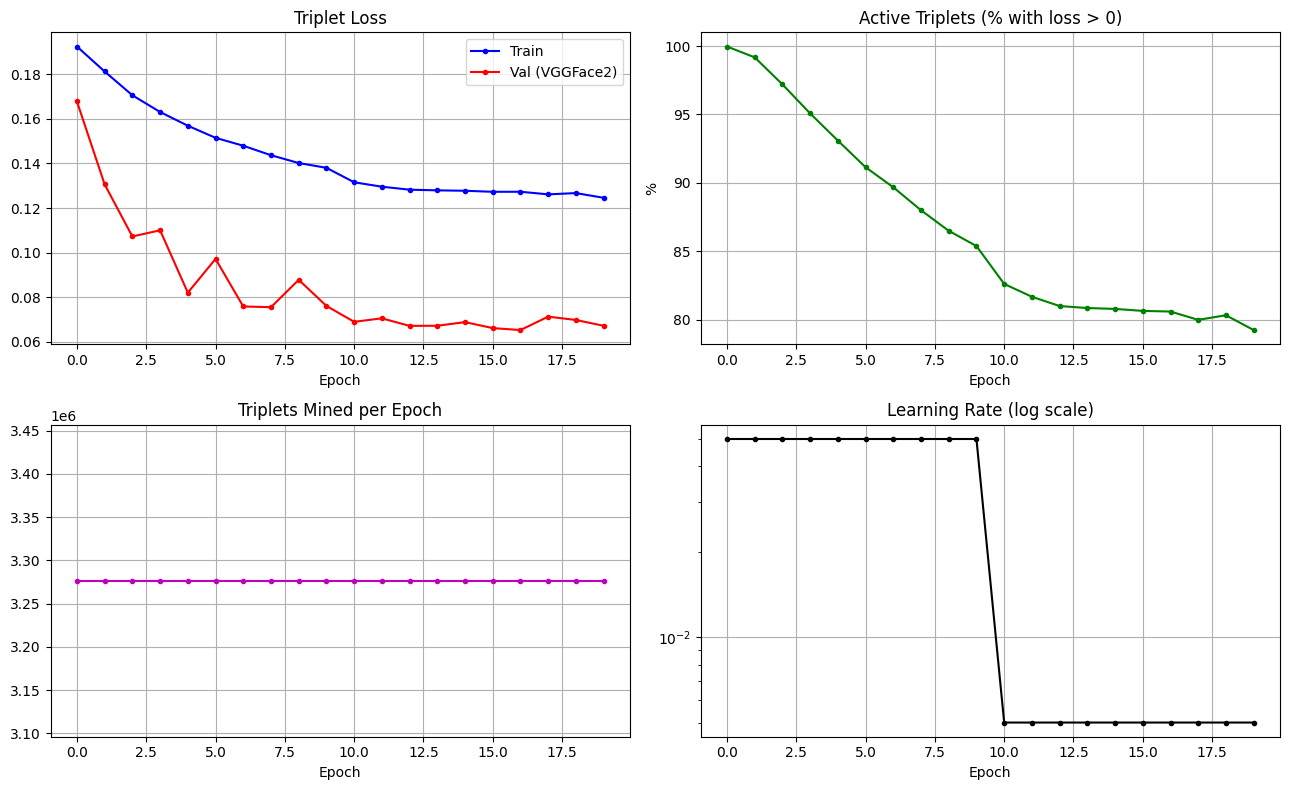

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(history['train_loss'], 'b-o', ms=3, label='Train')
axes[0,0].plot(history['val_loss'],   'r-o', ms=3, label='Val (VGGFace2)')
axes[0,0].set_title('Triplet Loss'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(history['active_pct'], 'g-o', ms=3)
axes[0,1].set_title('Active Triplets (% with loss > 0)')
axes[0,1].set_ylabel('%'); axes[0,1].grid(True)

axes[1,0].plot(history['n_triplets'], 'm-o', ms=3)
axes[1,0].set_title('Triplets Mined per Epoch'); axes[1,0].grid(True)

axes[1,1].plot(history['lr'], 'k-o', ms=3)
axes[1,1].set_title('Learning Rate (log scale)')
axes[1,1].set_yscale('log'); axes[1,1].grid(True)

for ax in axes.flat: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(os.path.join(cfg.LOG_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 11. Evaluation on VGGFace2 Val Set

VGGFace2's val set has 500 disjoint identities — compute **VAL @ FAR=10⁻³**.

In [24]:
best_ckpt = os.path.join(cfg.CHECKPOINT_DIR, 'nn2_vggface2_best.pt')
if os.path.exists(best_ckpt):
    ckpt = torch.load(best_ckpt, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    print(f'Loaded best checkpoint  epoch={ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.4f}')


@torch.no_grad()
def extract_embeddings(model, loader, device):
    model.eval()
    all_embs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='Extracting', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        all_embs.append(model(imgs).cpu())
        all_labels.append(labels)
    return torch.cat(all_embs), torch.cat(all_labels)


val_embs, val_labels = extract_embeddings(model, val_loader, DEVICE)
print(f'Val embeddings: {val_embs.shape}')

Loaded best checkpoint  epoch=17  val_loss=0.0653


Val embeddings: torch.Size([169396, 128])


VGGFace2 Val ROC
  AUC                    : 0.9645
  VAL @ FAR=0.001 : 19.82%


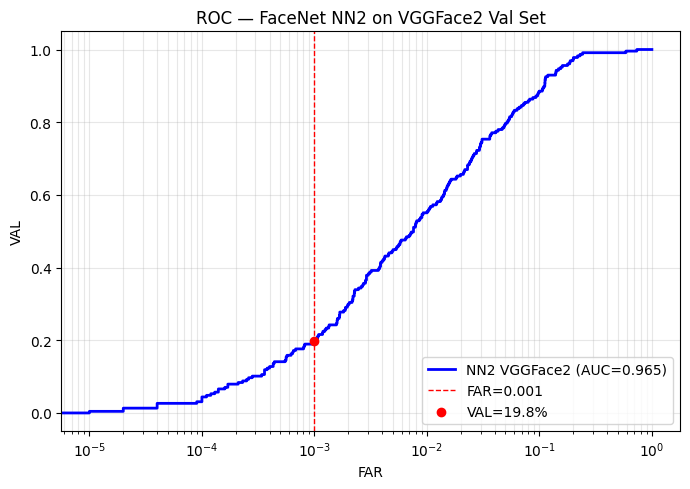

In [25]:
def compute_val_far(embeddings, labels, n_pairs=100_000):
    N     = len(embeddings)
    idx_a = np.random.randint(0, N, n_pairs)
    idx_b = np.random.randint(0, N, n_pairs)
    valid = idx_a != idx_b
    idx_a, idx_b = idx_a[valid], idx_b[valid]

    dists  = (embeddings[idx_a] - embeddings[idx_b]).pow(2).sum(1).numpy()
    same   = (labels[idx_a] == labels[idx_b]).numpy()

    fpr, tpr, _ = roc_curve(same, -dists)
    roc_auc     = auc(fpr, tpr)
    val_at_far  = tpr[np.searchsorted(fpr, cfg.FAR_TARGET)]

    return fpr, tpr, roc_auc, val_at_far


fpr, tpr, roc_auc, val_1e3 = compute_val_far(val_embs, val_labels)

print(f'VGGFace2 Val ROC')
print(f'  AUC                    : {roc_auc:.4f}')
print(f'  VAL @ FAR={cfg.FAR_TARGET} : {val_1e3*100:.2f}%')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, 'b-', lw=2, label=f'NN2 VGGFace2 (AUC={roc_auc:.3f})')
ax.axvline(cfg.FAR_TARGET, color='r', ls='--', lw=1, label=f'FAR={cfg.FAR_TARGET}')
ax.scatter([cfg.FAR_TARGET], [val_1e3], color='r', zorder=5,
           label=f'VAL={val_1e3*100:.1f}%')
ax.set_xscale('log')
ax.set_xlabel('FAR'); ax.set_ylabel('VAL')
ax.set_title('ROC — FaceNet NN2 on VGGFace2 Val Set')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.LOG_DIR, 'roc_vggface2_val.png'), dpi=150)
plt.show()

## 12. Evaluation on LFW (Paper Protocol §5.6)

In [26]:
import os
print(os.listdir('/kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled'))

['lfw-deepfunneled']


In [27]:
class Config:
    INPUT_SIZE    = 160
    EMBEDDING_DIM = 128

    MARGIN        = 0.2

    LEARNING_RATE  = 0.05
    LR_DECAY_STEP  = 10
    LR_DECAY_GAMMA = 0.1

    FACES_PER_ID   = 20
    IDS_PER_BATCH  = 18
    BATCH_SIZE     = FACES_PER_ID * IDS_PER_BATCH

    NUM_EPOCHS      = 10       # hard upper limit
    EARLY_STOP_PATIENCE = 3    # stop if val_loss doesn't improve for this many epochs
    MIXED_PRECISION = True
    GRAD_CLIP       = 5.0

    DATASET_ROOT = '/kaggle/input/datasets/huphuoc09/vgg-face2-cs338/VGG-Face2/data'
    TRAIN_DIR    = DATASET_ROOT + '/vggface2_train/train'
    VAL_DIR      = DATASET_ROOT + '/vggface2_test/test'
    MIN_IMAGES   = 20


    LFW_DIR        = '/kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled'
    LFW_PAIRS_FILE = '/kaggle/input/datasets/jessicali9530/lfw-dataset/pairs.csv'

    FAR_TARGET = 1e-3
    THRESHOLD  = 1.242

    CHECKPOINT_DIR = '/kaggle/working/checkpoints'
    LOG_DIR        = '/kaggle/working/logs'


cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(cfg.LOG_DIR, exist_ok=True)
print(f'Train dir : {cfg.TRAIN_DIR}')
print(f'Val   dir : {cfg.VAL_DIR}')
print(f'LFW   dir : {cfg.LFW_DIR}')
print(f'LFW pairs : {cfg.LFW_PAIRS_FILE}')

Train dir : /kaggle/input/datasets/huphuoc09/vgg-face2-cs338/VGG-Face2/data/vggface2_train/train
Val   dir : /kaggle/input/datasets/huphuoc09/vgg-face2-cs338/VGG-Face2/data/vggface2_test/test
LFW   dir : /kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled
LFW pairs : /kaggle/input/datasets/jessicali9530/lfw-dataset/pairs.csv


In [28]:
import pandas as pd

df = pd.read_csv(cfg.LFW_PAIRS_FILE)
print(df.columns.tolist())
print(df.head(3))

['name', 'imagenum1', 'imagenum2', 'Unnamed: 3']
             name  imagenum1 imagenum2  Unnamed: 3
0    Abel_Pacheco          1         4         NaN
1  Akhmed_Zakayev          1         3         NaN
2  Akhmed_Zakayev          2         3         NaN


In [29]:
print(df.shape)
print(df.dropna().head(3))
print(df[df['Unnamed: 3'].notna()].head(3))

(6000, 4)
                   name  imagenum1             imagenum2  Unnamed: 3
300  Abdel_Madi_Shabneh          1           Dean_Barker         1.0
301  Abdel_Madi_Shabneh          1  Giancarlo_Fisichella         1.0
302  Abdel_Madi_Shabneh          1     Mikhail_Gorbachev         1.0
                   name  imagenum1             imagenum2  Unnamed: 3
300  Abdel_Madi_Shabneh          1           Dean_Barker         1.0
301  Abdel_Madi_Shabneh          1  Giancarlo_Fisichella         1.0
302  Abdel_Madi_Shabneh          1     Mikhail_Gorbachev         1.0


In [30]:
# Check what the actual image filenames look like
import os
sample_person = os.listdir(cfg.LFW_DIR)[0]
print('Person folder:', sample_person)
print('Images inside:', os.listdir(os.path.join(cfg.LFW_DIR, sample_person))[:3])

# Check what path we're generating vs what exists
row = df.iloc[0]
name1 = str(row['name'])
i1    = int(row['imagenum1'])
generated = str(Path(cfg.LFW_DIR) / name1 / f'{name1}_{i1:04d}.jpg')
print('Generated path:', generated)
print('Exists:', os.path.exists(generated))

Person folder: Tyler_Hamilton
Images inside: ['Tyler_Hamilton_0002.jpg', 'Tyler_Hamilton_0001.jpg']
Generated path: /kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Abel_Pacheco/Abel_Pacheco_0001.jpg
Exists: True


In [31]:
def parse_lfw_pairs(pairs_file, lfw_root):
    root = Path(lfw_root)
    df   = pd.read_csv(pairs_file)
    pairs = []
    for _, row in df.iterrows():
        name1 = str(row['name'])
        i1    = int(row['imagenum1'])
        
        # Check if same or different person
        try:
            i2 = int(row['imagenum2'])   # same person — imagenum2 is a number
            p1 = root / name1 / f'{name1}_{i1:04d}.jpg'
            p2 = root / name1 / f'{name1}_{i2:04d}.jpg'
            pairs.append((str(p1), str(p2), 1))
        except (ValueError, TypeError):
            name2 = str(row['imagenum2'])  # different person — imagenum2 is a name
            i2    = int(row['Unnamed: 3'])
            p1 = root / name1 / f'{name1}_{i1:04d}.jpg'
            p2 = root / name2 / f'{name2}_{i2:04d}.jpg'
            pairs.append((str(p1), str(p2), 0))

    return [(p1, p2, s) for p1, p2, s in pairs
            if os.path.exists(p1) and os.path.exists(p2)]

lfw_pairs = parse_lfw_pairs(cfg.LFW_PAIRS_FILE, cfg.LFW_DIR)
print(f'LFW pairs: {len(lfw_pairs):,}  '
      f'(same={sum(s for _,_,s in lfw_pairs):,}  '
      f'diff={sum(1-s for _,_,s in lfw_pairs):,})')

LFW pairs: 6,000  (same=3,000  diff=3,000)


In [32]:
@torch.no_grad()
def embed_path_list(model, paths, transform, device, batch_size=256):
    model.eval()
    unique = list(set(paths))
    emb_map = {}
    for i in tqdm(range(0, len(unique), batch_size),
                  desc='Embedding LFW', leave=False):
        batch = unique[i : i+batch_size]
        imgs  = torch.stack([
            transform(Image.open(p).convert('RGB')) for p in batch
        ]).to(device)
        embs = model(imgs).cpu()
        for path, emb in zip(batch, embs):
            emb_map[path] = emb.numpy()
    return emb_map


all_paths = [p for pair in lfw_pairs for p in pair[:2]]
emb_map   = embed_path_list(model, all_paths, eval_transform, DEVICE)
print(f'Embedded {len(emb_map):,} unique LFW images.')

Embedded 7,701 unique LFW images.


In [33]:
def lfw_10fold(pairs, emb_map, n_splits=10):
    n         = len(pairs)
    fold_size = n // n_splits
    accs, thrs = [], []

    for test_fold in range(n_splits):
        test  = pairs[test_fold*fold_size : (test_fold+1)*fold_size]
        train = pairs[:test_fold*fold_size] + pairs[(test_fold+1)*fold_size:]

        tr_dists  = np.array([np.sum((emb_map[p1]-emb_map[p2])**2)
                               for p1,p2,_ in train])
        tr_labels = np.array([s for _,_,s in train])

        best_t, best_a = 0., 0.
        for t in np.arange(0.0, 4.0, 0.01):
            a = ((tr_dists <= t).astype(int) == tr_labels).mean()
            if a > best_a: best_a, best_t = a, t

        te_dists  = np.array([np.sum((emb_map[p1]-emb_map[p2])**2)
                               for p1,p2,_ in test])
        te_labels = np.array([s for _,_,s in test])
        te_acc    = ((te_dists <= best_t).astype(int) == te_labels).mean()

        accs.append(te_acc); thrs.append(best_t)

    return np.array(accs), np.array(thrs)


fold_accs, fold_thrs = lfw_10fold(lfw_pairs, emb_map)

print('─' * 48)
print('LFW 10-Fold Results')
print('─' * 48)
for i, (a, t) in enumerate(zip(fold_accs, fold_thrs)):
    print(f'  Fold {i+1:2d} : {a*100:.2f}%   threshold={t:.3f}')
print('─' * 48)
print(f'  Mean  : {fold_accs.mean()*100:.2f}% ± {fold_accs.std()*100:.2f}%')
print(f'  Paper : 98.87% (NN1) | 99.63% (NN1 + alignment)')
print('─' * 48)

────────────────────────────────────────────────
LFW 10-Fold Results
────────────────────────────────────────────────
  Fold  1 : 94.83%   threshold=0.860
  Fold  2 : 91.83%   threshold=0.860
  Fold  3 : 91.00%   threshold=0.860
  Fold  4 : 92.33%   threshold=0.860
  Fold  5 : 92.50%   threshold=0.860
  Fold  6 : 92.50%   threshold=0.860
  Fold  7 : 94.00%   threshold=0.860
  Fold  8 : 92.50%   threshold=0.860
  Fold  9 : 92.67%   threshold=0.860
  Fold 10 : 95.33%   threshold=0.860
────────────────────────────────────────────────
  Mean  : 92.95% ± 1.28%
  Paper : 98.87% (NN1) | 99.63% (NN1 + alignment)
────────────────────────────────────────────────


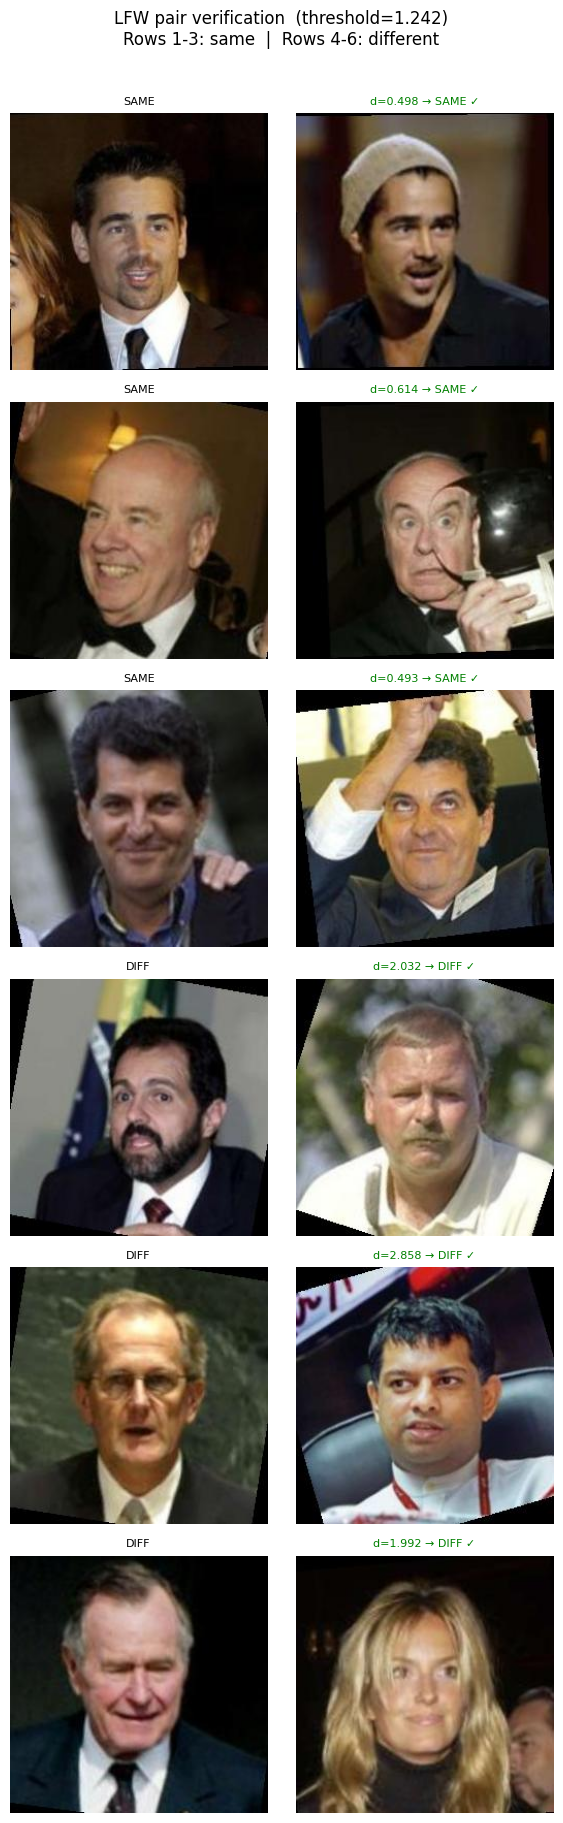

In [40]:
import random

@torch.no_grad()
def embed_image(model, img_input, transform=None, device=DEVICE):
    if transform is None:
        transform = eval_transform
    if isinstance(img_input, (str, Path)):
        img_input = Image.open(img_input).convert('RGB')
    t = transform(img_input).unsqueeze(0).to(device)
    model.eval()
    return model(t).squeeze(0).cpu().numpy()

def face_distance(e1, e2):
    return float(np.sum((e1 - e2) ** 2))

def verify(e1, e2, threshold=None):
    if threshold is None: threshold = cfg.THRESHOLD
    d = face_distance(e1, e2)
    return d <= threshold, d

same_pairs = [(p1,p2) for p1,p2,s in lfw_pairs if s==1]
diff_pairs = [(p1,p2) for p1,p2,s in lfw_pairs if s==0]

same_demo = random.sample(same_pairs, 3)
diff_demo = random.sample(diff_pairs, 3)

demo = [(p1,p2,True)  for p1,p2 in same_demo] + \
       [(p1,p2,False) for p1,p2 in diff_demo]

fig, axes = plt.subplots(6, 2, figsize=(6, 18))
for row, (p1, p2, gt_same) in enumerate(demo):
    e1 = embed_image(model, p1)
    e2 = embed_image(model, p2)
    pred_same, dist = verify(e1, e2)
    correct = pred_same == gt_same
    colour  = 'green' if correct else 'red'

    axes[row, 0].imshow(Image.open(p1).convert('RGB'))
    axes[row, 0].axis('off')
    axes[row, 0].set_title('SAME' if gt_same else 'DIFF', fontsize=8)

    axes[row, 1].imshow(Image.open(p2).convert('RGB'))
    axes[row, 1].axis('off')
    axes[row, 1].set_title(
        f'd={dist:.3f} → {"SAME" if pred_same else "DIFF"} {"✓" if correct else "✗"}',
        fontsize=8, color=colour)

plt.suptitle(f'LFW pair verification  (threshold={cfg.THRESHOLD})\n'
             f'Rows 1-3: same  |  Rows 4-6: different', y=1.01)
plt.tight_layout()
plt.show()

## 13. Saving & Loading Checkpoints

In [41]:
def save_checkpoint(model, optimizer, epoch, val_loss, path):
    torch.save({
        'epoch':       epoch,
        'model_state': model.state_dict(),
        'optim_state': optimizer.state_dict(),
        'val_loss':    val_loss,
        'config': {
            'embedding_dim': cfg.EMBEDDING_DIM,
            'input_size':    cfg.INPUT_SIZE,
            'margin':        cfg.MARGIN,
        },
    }, path)
    print(f'Saved → {path}')


def load_checkpoint(path, device=DEVICE):
    ckpt = torch.load(path, map_location=device)
    c    = ckpt.get('config', {})
    net  = NN2(embedding_dim=c.get('embedding_dim', 128)).to(device)
    net.load_state_dict(ckpt['model_state'])
    net.eval()
    print(f'Loaded  epoch={ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.4f}')
    return net, ckpt


save_checkpoint(
    model, optimizer, cfg.NUM_EPOCHS,
    history['val_loss'][-1],
    os.path.join(cfg.CHECKPOINT_DIR, 'nn2_vggface2_final.pt')
)

Saved → /kaggle/working/checkpoints/nn2_vggface2_final.pt


## 14. Inference — Embeddings & Verification

In [42]:
torch.save(model.state_dict(), '/kaggle/working/facenet_model.pth')
print("Model saved!")

Model saved!


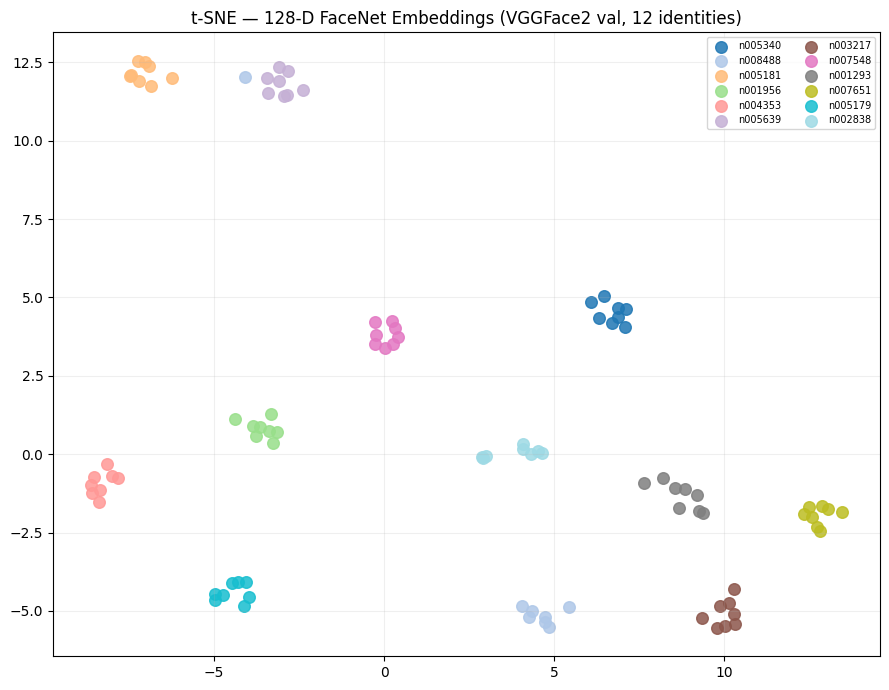

Tight per-identity clusters = good embedding quality.


In [43]:
from sklearn.manifold import TSNE

N_IDS = 12; IMGS_PER_ID = 8
chosen = random.sample(list(val_dataset.label_to_indices.keys()), N_IDS)

vis_embs, vis_labels = [], []
for lbl in chosen:
    for idx in val_dataset.label_to_indices[lbl][:IMGS_PER_ID]:
        img = Image.open(val_dataset.image_paths[idx]).convert('RGB')
        vis_embs.append(embed_image(model, img))
        vis_labels.append(lbl)

vis_embs   = np.array(vis_embs)
vis_labels = np.array(vis_labels)

coords = TSNE(n_components=2, perplexity=15, random_state=SEED).fit_transform(vis_embs)

fig, ax = plt.subplots(figsize=(9, 7))
colors  = plt.cm.tab20(np.linspace(0, 1, N_IDS))
for i, lbl in enumerate(chosen):
    mask = vis_labels == lbl
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=colors[i],
               label=val_dataset.label_to_name[lbl],
               s=70, alpha=0.85)
ax.legend(fontsize=7, ncol=2)
ax.set_title('t-SNE — 128-D FaceNet Embeddings (VGGFace2 val, 12 identities)')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(cfg.LOG_DIR, 'tsne_vggface2.png'), dpi=150)
plt.show()
print('Tight per-identity clusters = good embedding quality.')

---
## Paper ↔ Code Reference

| Paper element | Code | Fix applied |
|---|---|---|
| NN2 / NN3 architecture (Table 2) | `class NN2` + `InceptionModule` + `L2Pool2d` | ✓ pool_proj guard |
| Triplet loss Eq. (3) | `class TripletLoss` | — |
| Semi-hard negatives §3.2 | `build_triplet_indices()` | ✓ explicit detach |
| ~40 faces/identity per batch §3.2 | `BalancedBatchSampler` | ✓ 20 for Kaggle VRAM |
| AdaGrad lr=0.05 §3.3 | `torch.optim.Adagrad` | — |
| L2 normalisation §3.1 | `F.normalize(x, p=2, dim=1)` | — |
| 128-D embedding §5.4 | `cfg.EMBEDDING_DIM=128` | — |
| Validation loss | `validate()` | ✓ now uses semi-hard mining |
| AMP / mixed precision | `torch.amp.GradScaler` | ✓ new API only |
| LFW paths | `cfg.LFW_DIR / LFW_PAIRS_FILE` | ✓ uncommented & fixed |
| Kaggle paths | `cfg.TRAIN_DIR / VAL_DIR` | ✓ /kaggle/input/... |
| DataLoader workers | `num_workers=4` | ✓ Kaggle Linux, not 0 |

## 15. Final Model Download Link

In [44]:
from IPython.display import FileLink
FileLink('checkpoints/nn2_vggface2_final.pt')

/kaggle/working/checkpoints/nn2_vggface2_final.pt